In [1]:
print(5)

5


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
BASE_DIR = Path.cwd().parent

RESULTS_PATH = BASE_DIR / "model_comparison_results.csv"

print("Results file exists:", RESULTS_PATH.exists())

Results file exists: True


In [4]:
results_df = pd.read_csv(RESULTS_PATH)

results_df

,model,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,MobileNetV2,0.998117,0.991122,0.984913,0.987888,0.998099
1,VGG16,0.996862,0.989891,0.983943,0.986782,0.996844
2,ResNet50,0.997490,0.970907,0.984842,0.977127,0.997600
3,InceptionV3,0.994352,0.950949,0.982683,0.962161,0.994941
4,EfficientNetB0,0.992469,0.945035,0.982168,0.957153,0.993289


In [5]:
# Sorting models by F1 score

results_df = results_df.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

results_df

,model,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,MobileNetV2,0.998117,0.991122,0.984913,0.987888,0.998099
1,VGG16,0.996862,0.989891,0.983943,0.986782,0.996844
2,ResNet50,0.997490,0.970907,0.984842,0.977127,0.997600
3,InceptionV3,0.994352,0.950949,0.982683,0.962161,0.994941
4,EfficientNetB0,0.992469,0.945035,0.982168,0.957153,0.993289


In [6]:
formatted_results = results_df.copy()

metric_columns = [
    "test_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1"
]

formatted_results[metric_columns] = formatted_results[metric_columns].round(4)

formatted_results

,model,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,MobileNetV2,0.9981,0.9911,0.9849,0.9879,0.9981
1,VGG16,0.9969,0.9899,0.9839,0.9868,0.9968
2,ResNet50,0.9975,0.9709,0.9848,0.9771,0.9976
3,InceptionV3,0.9944,0.9509,0.9827,0.9622,0.9949
4,EfficientNetB0,0.9925,0.9450,0.9822,0.9572,0.9933


In [7]:
# Identifying the best model

best_model = results_df.iloc[0]

print("Best Model:", best_model["model"])
print(f"Test Accuracy: {best_model['test_accuracy']:.4f}")
print(f"Macro Precision: {best_model['macro_precision']:.4f}")
print(f"Macro Recall: {best_model['macro_recall']:.4f}")
print(f"Macro F1-score: {best_model['macro_f1']:.4f}")
print(f"Weighted F1-score: {best_model['weighted_f1']:.4f}")

Best Model: MobileNetV2
Test Accuracy: 0.9981
Macro Precision: 0.9911
Macro Recall: 0.9849
Macro F1-score: 0.9879
Weighted F1-score: 0.9981


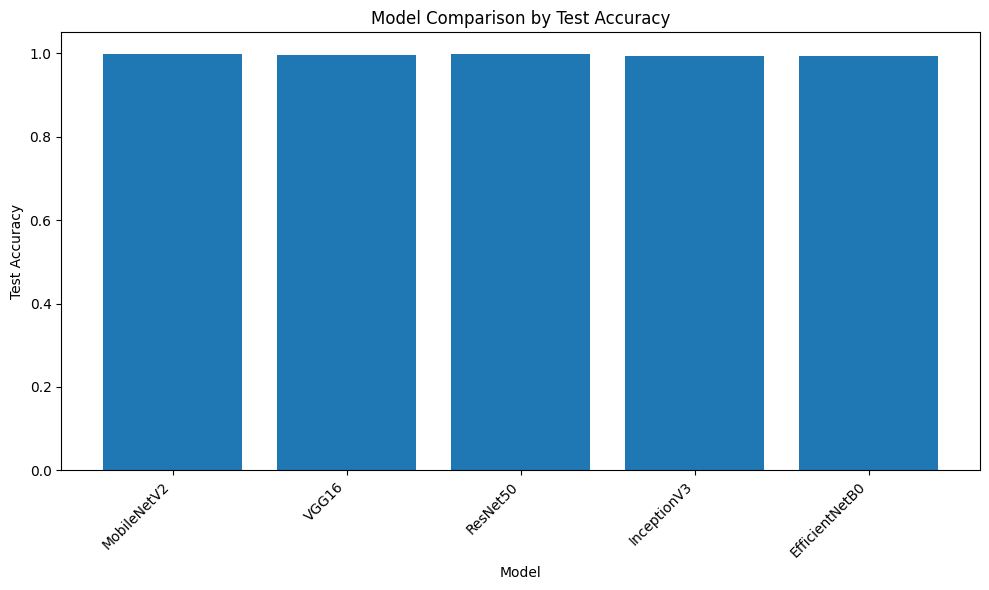

In [8]:
# Test accuracy chart

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["model"],
    results_df["test_accuracy"]
)

plt.title("Model Comparison by Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

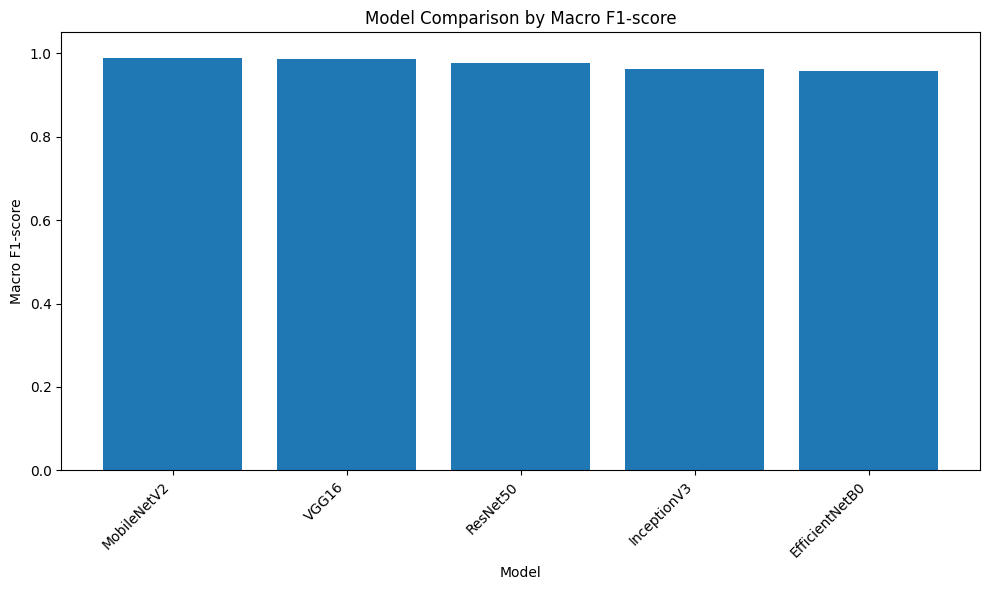

In [9]:
# F1 Score chart

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["model"],
    results_df["macro_f1"]
)

plt.title("Model Comparison by Macro F1-score")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

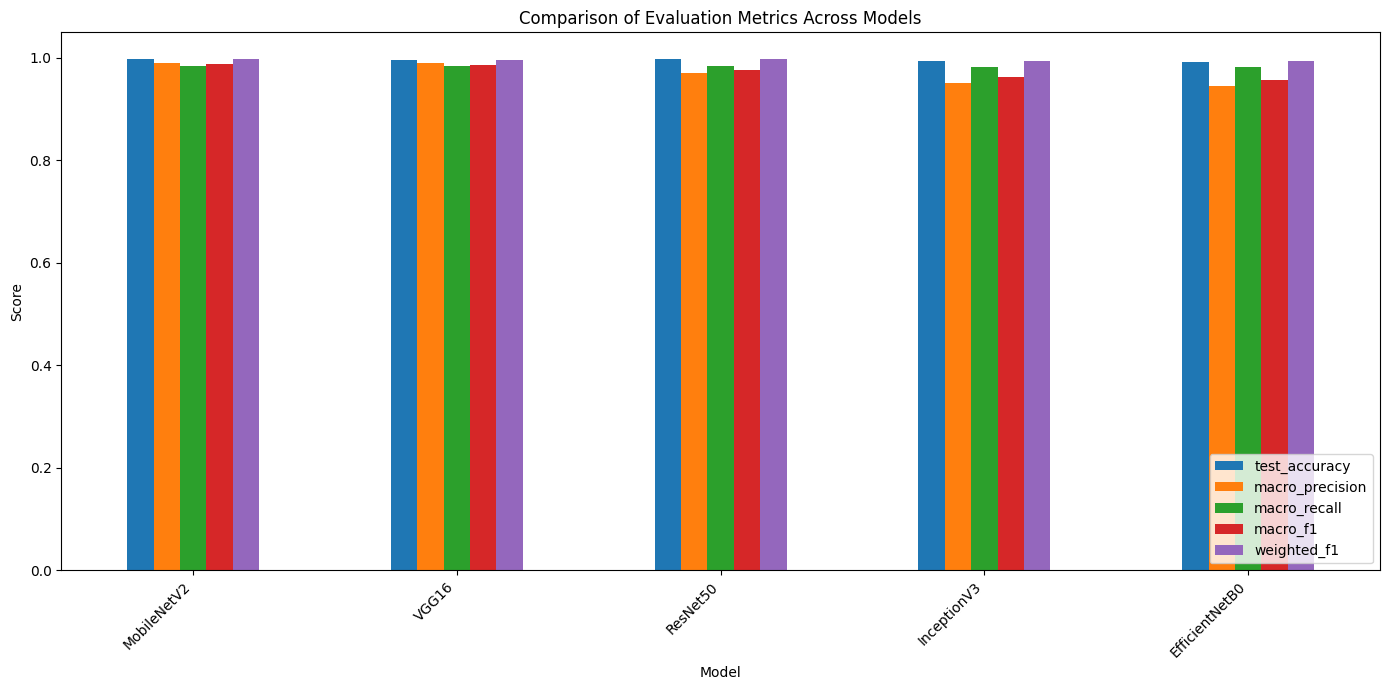

In [ ]:
# Comparing metrics

comparison_plot_df = results_df.set_index("model")[
    [
        "test_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1"
    ]
]

comparison_plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparison of Evaluation Metrics Across Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [12]:
best_model_name = best_model["model"]
best_macro_f1 = best_model["macro_f1"]
best_accuracy = best_model["test_accuracy"]

print(f'Best Model: {best_model_name}')
print(f'Best Macro F1 score: {best_macro_f1}')
print(f'Best Accuracy Score: {best_accuracy}')

Best Model: MobileNetV2
Best Macro F1 score: 0.9878880379359366
Best Accuracy Score: 0.9981173276901244


In [13]:
# Saving sorted table

sorted_results_path = BASE_DIR / "sorted_model_comparison_results.csv"

results_df.to_csv(sorted_results_path, index=False)

print("Sorted comparison table saved to:", sorted_results_path)

Sorted comparison table saved to: e:\Guvi\Projects\Assignment 5\fish_image_classification\sorted_model_comparison_results.csv


In [ ]:
import shutil

In [15]:
MODEL_FILE_MAP = {
    "EfficientNetB0": "efficientnetb0_finetuned.h5",
    "MobileNetV2": "mobilenetv2_finetuned.h5",
    "ResNet50": "resnet50_finetuned.h5",
    "VGG16": "vgg16_finetuned.h5",
    "InceptionV3": "inceptionv3_finetuned.h5"
}

source_model_path = BASE_DIR / "models" / MODEL_FILE_MAP[best_model_name]
destination_model_path = BASE_DIR / "models" / "best_fish_classifier.h5"

shutil.copy2(source_model_path, destination_model_path)

WindowsPath('e:/Guvi/Projects/Assignment 5/fish_image_classification/models/best_fish_classifier.h5')

In [16]:
best_model_metadata = pd.DataFrame([{
    "best_model": best_model_name,
    "test_accuracy": best_model["test_accuracy"],
    "macro_precision": best_model["macro_precision"],
    "macro_recall": best_model["macro_recall"],
    "macro_f1": best_model["macro_f1"],
    "weighted_f1": best_model["weighted_f1"]
}])

best_model_metadata.to_csv(
    BASE_DIR / "best_model_metadata.csv",
    index=False
)

best_model_metadata

,best_model,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,MobileNetV2,0.998117,0.991122,0.984913,0.987888,0.998099
